# Music Generation with Transformer

## 1.1 Dependencies

In [ ]:
# Import Tensorflow 2.0
#%tensorflow_version 2.x
import tensorflow as tf

# Download and import the MIT 6.S191 package
!pip install mitdeeplearning
import mitdeeplearning as mdl
!pip install datasets

# Import all remaining packages
import numpy as np
import os
import time
import functools
from IPython import display as ipythondisplay
from tqdm import tqdm
!apt-get install abcmidi timidity > /dev/null 2>&1

## 1.2 Dataset

In [ ]:
# Download the dataset
songs = mdl.lab1.load_training_data()

# Print one of the songs to inspect it in greater detail!
example_song = songs[0]
print("\nExample song: ")
print(example_song)

In [ ]:
# Convert the ABC notation to audio file and listen to it
mdl.lab1.play_song(example_song)

In [ ]:
# Join our list of song strings into a single string containing all songs
songs_joined = "\n\n".join(songs)

# Find all unique characters in the joined string
vocab = sorted(set(songs_joined))
print("There are", len(vocab), "unique characters in the dataset")

## 1.3 Process the dataset for the learning task

### Vectorize the text

In [ ]:
### Define numerical representation of text ###

# Create a mapping from character to unique index.
# For example, to get the index of the character "d",
#   we can evaluate `char2idx["d"]`.
char2idx = {u:i for i, u in enumerate(vocab)}

# Create a mapping from indices to characters. This is
#   the inverse of char2idx and allows us to convert back
#   from unique index to the character in our vocabulary.
idx2char = np.array(vocab)

In [ ]:
print('{')
for char,_ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

In [ ]:
### Vectorize the songs string ###

'''TODO: Write a function to convert the all songs string to a vectorized
    (i.e., numeric) representation. Use the appropriate mapping
    above to convert from vocab characters to the corresponding indices.

  NOTE: the output of the `vectorize_string` function
  should be a np.array with `N` elements, where `N` is
  the number of characters in the input string
'''

def vectorize_string(string):
  vectorized_songs = np.array([char2idx[song] for song in string ])
  return vectorized_songs
vectorized_songs = vectorize_string(songs_joined)

In [ ]:
print ('{} ---- characters mapped to int ----> {}'.format(repr(songs_joined[:10]), vectorized_songs[:10]))
# check that vectorized_songs is a numpy array
assert isinstance(vectorized_songs, np.ndarray), "returned result should be a numpy array"

### Create training examples and targets

In [ ]:
### Batch definition to create training examples ###

def get_batch(vectorized_songs, seq_length, batch_size):
  # the length of the vectorized songs string
  n = vectorized_songs.shape[0] - 1
  # randomly choose the starting indices for the examples in the training batch
  idx = np.random.choice(n-seq_length, batch_size)

  '''TODO: construct a list of input sequences for the training batch'''
  input_batch = [vectorized_songs[i:i+seq_length] for i in idx]
  '''TODO: construct a list of output sequences for the training batch'''
  output_batch = [vectorized_songs[i+1:i+seq_length+1] for i in idx]

  # x_batch, y_batch provide the true inputs and targets for network training
  x_batch = np.reshape(input_batch, [batch_size, seq_length])
  y_batch = np.reshape(output_batch, [batch_size, seq_length])
  return x_batch, y_batch


# Perform some simple tests to make sure your batch function is working properly!
test_args = (vectorized_songs, 10, 2)
if not mdl.lab1.test_batch_func_types(get_batch, test_args) or \
   not mdl.lab1.test_batch_func_shapes(get_batch, test_args) or \
   not mdl.lab1.test_batch_func_next_step(get_batch, test_args):
   print("======\n[FAIL] could not pass tests")
else:
   print("======\n[PASS] passed all tests!")

In [ ]:
x_batch, y_batch = get_batch(vectorized_songs, seq_length=5, batch_size=1)

for i, (input_idx, target_idx) in enumerate(zip(np.squeeze(x_batch), np.squeeze(y_batch))):
    print("Step {:3d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx])))

## 1.4 Define the Transformer model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Embedding, LayerNormalization, Dropout
from tensorflow.keras import Sequential

# --- Transformer Block with Causal Masking ---
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, attention_axes=(1,)
        )
        self.ffn = Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):
        seq_len = tf.shape(inputs)[1]
        # Causal attention mask to prevent attending to future tokens
        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        causal_mask = tf.reshape(causal_mask, (1, 1, seq_len, seq_len))  # Add batch dims

        attn_output = self.att(inputs, inputs, attention_mask=causal_mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# --- Embedding Layer ---
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# --- Create Transformer Model ---
def create_transformer_model(maxlen, vocab_size, embed_dim, num_heads, ff_dim, num_layers=2):
    inputs = tf.keras.Input(shape=(maxlen,))
    x = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)(inputs)

    for _ in range(num_layers):
        x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    x = Dense(ff_dim, activation="relu")(x)
    outputs = Dense(vocab_size)(x)  # Output shape: (batch, seq, vocab_size)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# --- Parameters ---
maxlen = 100               # Sequence length
vocab_size = len(vocab)    # Total unique tokens
embed_dim = 64             # Embedding size
num_heads = 4              # Attention heads
ff_dim = 128               # Feed-forward hidden layer size
num_layers = 2             # Number of transformer blocks

# --- Instantiate & Compile Model ---
model = create_transformer_model(maxlen, vocab_size, embed_dim, num_heads, ff_dim, num_layers)
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# --- Model Summary ---
model.summary()

### Test out the Transformer model

In [ ]:
# Generate a batch of input and target sequences
x, y = get_batch(vectorized_songs, seq_length=100, batch_size=32)

# Use the Transformer model to predict the next tokens in the sequence
pred = model(x)

# Display the shapes of input and prediction tensors
print("Input shape:      ", x.shape, " # (batch_size, sequence_length)")
print("Prediction shape: ", pred.shape, "# (batch_size, sequence_length, vocab_size)")

### Predictions from the untrained model

In [ ]:
# Reshape pred_tensor to 2D for tf.random.categorical
pred_tensor_2d = tf.reshape(pred, [-1, pred.shape[-1]])  # Shape becomes (100, 83)

# Sample indices from the probability distribution of predicted tokens
sampled_indices = tf.random.categorical(pred_tensor_2d, num_samples=1)
sampled_indices = tf.squeeze(sampled_indices, axis=-1).numpy()

# Print the sampled indices as characters
print("Sampled Indices:\n", sampled_indices)
print("Input: \n", repr("".join(idx2char[x[0]])))
print()
# Adjust indexing to match the reshaped pred_tensor_2d
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices])))

## 1.5 Training the model: loss and training operations

In [ ]:
def compute_loss(labels, logits):
    loss = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    return tf.reduce_mean(loss)

# Compute the loss using the true next characters from the example batch and the predictions from the untrained model
example_batch_loss = compute_loss(y, pred)

print("Prediction shape: ", pred.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())


In [ ]:
# Optimization parameters:
num_training_iterations = 50000  # Increase this to train longer
batch_size = 64  # Experiment between 1 and 64
seq_length = 100  # Experiment between 50 and 500
learning_rate = 1e-3  # Experiment between 1e-5 and 1e-1

# Model parameters:
vocab_size = len(vocab)
embedding_dim = 256
num_heads = 4
ff_dim = 1024  # Hidden layer size in feed-forward network

# Checkpoint location:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "my_ckpt")

# Instantiate the Transformer model for training
model = create_transformer_model(seq_length, vocab_size, embedding_dim, num_heads, ff_dim)

# Instantiate the Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate)

In [ ]:
# loss, optimizer and helpers must be defined before training:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def compute_loss(y_true, y_logits):
    # y_true: (batch, seq), y_logits: (batch, seq, vocab)
    per_token_loss = loss_fn(y_true, y_logits)        # (batch, seq)
    per_example_loss = tf.reduce_mean(per_token_loss, axis=1)  # (batch,)
    return tf.reduce_mean(per_example_loss)           # scalar

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        y_hat = model(x, training=True)               # (batch, seq, vocab)
        loss = compute_loss(y, y_hat)
    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)     # optional clipping
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# Training loop (run in Python - not inside @tf.function)
history = []
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss')
os.makedirs(checkpoint_dir, exist_ok=True)

for iter in tqdm(range(num_training_iterations)):
    x_batch, y_batch = get_batch(vectorized_songs, seq_length, batch_size)
    # ensure tensors, e.g.:
    x_batch = tf.convert_to_tensor(x_batch, dtype=tf.int32)
    y_batch = tf.convert_to_tensor(y_batch, dtype=tf.int32)

    loss = train_step(x_batch, y_batch)
    loss_val = float(loss.numpy())   # scalar for logging/plotting
    history.append(loss_val)
    plotter.plot(history)

    if iter % 100 == 0:
        try:
            model.save_weights(checkpoint_prefix + '.weights.h5')
        except Exception as e:
            print("Save failed:", e)

# final save
model.save_weights(checkpoint_prefix + '.weights.h5')

## 1.6 Evaluation of Model

**Calculation of Accuracy**

In [ ]:
import tensorflow as tf
import numpy as np

def calculate_accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    correct_predictions = tf.equal(y_true, y_pred)
    accuracy = tf.reduce_mean(tf.cast(correct_predictions, tf.float32))
    return accuracy

def evaluate_accuracy(model, dataset):
    accuracies = []

    for x_batch, y_batch in dataset:
        y_pred = model(x_batch, training=False)
        batch_accuracy = calculate_accuracy(y_batch, y_pred)
        accuracies.append(batch_accuracy.numpy())  # Convert to NumPy outside the function

    mean_accuracy = np.mean(accuracies)
    print(f"Accuracy: {mean_accuracy:.4f}")
    return mean_accuracy

# Evaluate the model's accuracy using a single batch
x_val, y_val = get_batch(vectorized_songs, seq_length=100, batch_size=32)
val_dataset = [(x_val, y_val)]

# Evaluate
mean_accuracy = evaluate_accuracy(model, val_dataset)

**Calculation of Chord Accuracy, Note Accuracy and Perplexity**

In [ ]:
# --- Example usage ---
# full_dataset = create_dataset(vectorized_songs, seq_length=100, batch_size=4)
# avg_note_acc, avg_perplex = evaluate_model(model, full_dataset)
# transformer_evaluation.py
import tensorflow as tf
import numpy as np

# --- Note-level accuracy (Transformer) ---
def compute_accuracy(labels, logits):
    """
    labels: (batch, seq) int ids
    logits: (batch, seq, vocab) raw logits
    returns: float accuracy over tokens
    """
    labels = tf.cast(labels, tf.int32)
    predictions = tf.argmax(logits, axis=-1, output_type=tf.int32)
    correct = tf.equal(predictions, labels)
    correct = tf.cast(correct, tf.float32)
    return float(tf.reduce_mean(correct).numpy())

# --- Cross-entropy loss (per token) ---
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
def compute_loss(y_true, y_pred_logits):
    """
    returns per-token loss tensor shape (batch, seq)
    """
    return loss_fn(y_true, y_pred_logits)

# --- Perplexity ---
def calculate_perplexity(y_true, y_pred_logits):
    loss = compute_loss(y_true, y_pred_logits)            # (batch, seq)
    return float(tf.exp(tf.reduce_mean(loss)).numpy())

# --- Dataset creation from full vectorized data ---
def create_dataset(data, seq_length=100, batch_size=32):
    n = len(data) - 1
    inputs = [data[i:i+seq_length] for i in range(0, n - seq_length, seq_length)]
    targets = [data[i+1:i+seq_length+1] for i in range(0, n - seq_length, seq_length)]
    x = np.array(inputs)
    y = np.array(targets)
    return tf.data.Dataset.from_tensor_slices((x, y)).batch(batch_size, drop_remainder=True)

# --- Evaluation function for Transformer ---
def evaluate_model(model, dataset):
    total_loss = 0.0
    total_note_accuracy = 0.0
    total_perplexity = 0.0
    num_batches = 0

    for x_batch, y_batch in dataset:
        x_batch = tf.cast(x_batch, tf.int32)
        y_batch = tf.cast(y_batch, tf.int32)

        y_logits = model(x_batch, training=False)           # (batch, seq, vocab)
        loss = compute_loss(y_batch, y_logits)              # (batch, seq)
        note_acc = compute_accuracy(y_batch, y_logits)      # float
        perplex = calculate_perplexity(y_batch, y_logits)   # float

        total_loss += float(tf.reduce_mean(loss).numpy())
        total_note_accuracy += note_acc
        total_perplexity += perplex
        num_batches += 1

    if num_batches == 0:
        print("No batches in dataset.")
        return 0.0, 0.0

    avg_loss = total_loss / num_batches
    avg_note_accuracy = total_note_accuracy / num_batches
    avg_perplexity = total_perplexity / num_batches

    print(f"\n Evaluation Results:")
    print(f"- Average Loss     : {avg_loss:.4f}")
    print(f"- Note Accuracy    : {avg_note_accuracy:.4f}")
    print(f"- Perplexity       : {avg_perplexity:.4f}")

    return avg_note_accuracy, avg_perplexity

# --- Example usage ---
full_dataset = create_dataset(vectorized_songs, seq_length=100, batch_size=4)
avg_note_acc, avg_perplex = evaluate_model(model, full_dataset)

## 1.7 Generate music using the Transformer model

In [ ]:
# Rebuild the Transformer model with batch_size=1
def rebuild_transformer_model(vocab_size, embed_dim, num_heads, ff_dim):
    # Use the same function to build the model, but with batch_size=1
    maxlen = 100  # You can adjust this as needed
    model = create_transformer_model(maxlen, vocab_size, embed_dim, num_heads, ff_dim)
    return model

model = rebuild_transformer_model(vocab_size, embed_dim=256, num_heads=4, ff_dim=1024)

# Verify checkpoint directory and print available files
print("Checking for checkpoints in:", checkpoint_dir)
if os.path.exists(checkpoint_dir):
    checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith('my_ckpt')]
    if checkpoint_files:
        print("Found checkpoint files:", checkpoint_files)
        # Restore the model weights from the last checkpoint after training
        latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)
        if latest_checkpoint: # Check if a checkpoint was found
            model.load_weights(latest_checkpoint)
            print(f"Loaded weights from {latest_checkpoint}")
            model.build(tf.TensorShape([1, None]))
            model.summary()
        else:
            print("No checkpoint files found in the directory.")
    else:
        print("No checkpoint files found in the directory.")
else:
    print("Checkpoint directory not found.")

### The Prediction Procedure

Prediction Procedure for a Transformer Model
Initialize the "seed" start string and convert it to token indices. Set the number of tokens to generate.

Input the seed sequence into the Transformer to obtain the probability distribution over the next predicted token.

Sample from the probability distribution to get the index of the predicted token. Use this token as the next input to the model.

Append the predicted token to the sequence. The entire updated sequence is then fed back into the model for the next prediction.

Repeat the process: At each step, the Transformer uses the full sequence context via self-attention to predict the next token, leveraging positional encodings to maintain token order.

This method allows the Transformer to generate text with full sequence awareness at each step, ensuring coherent output.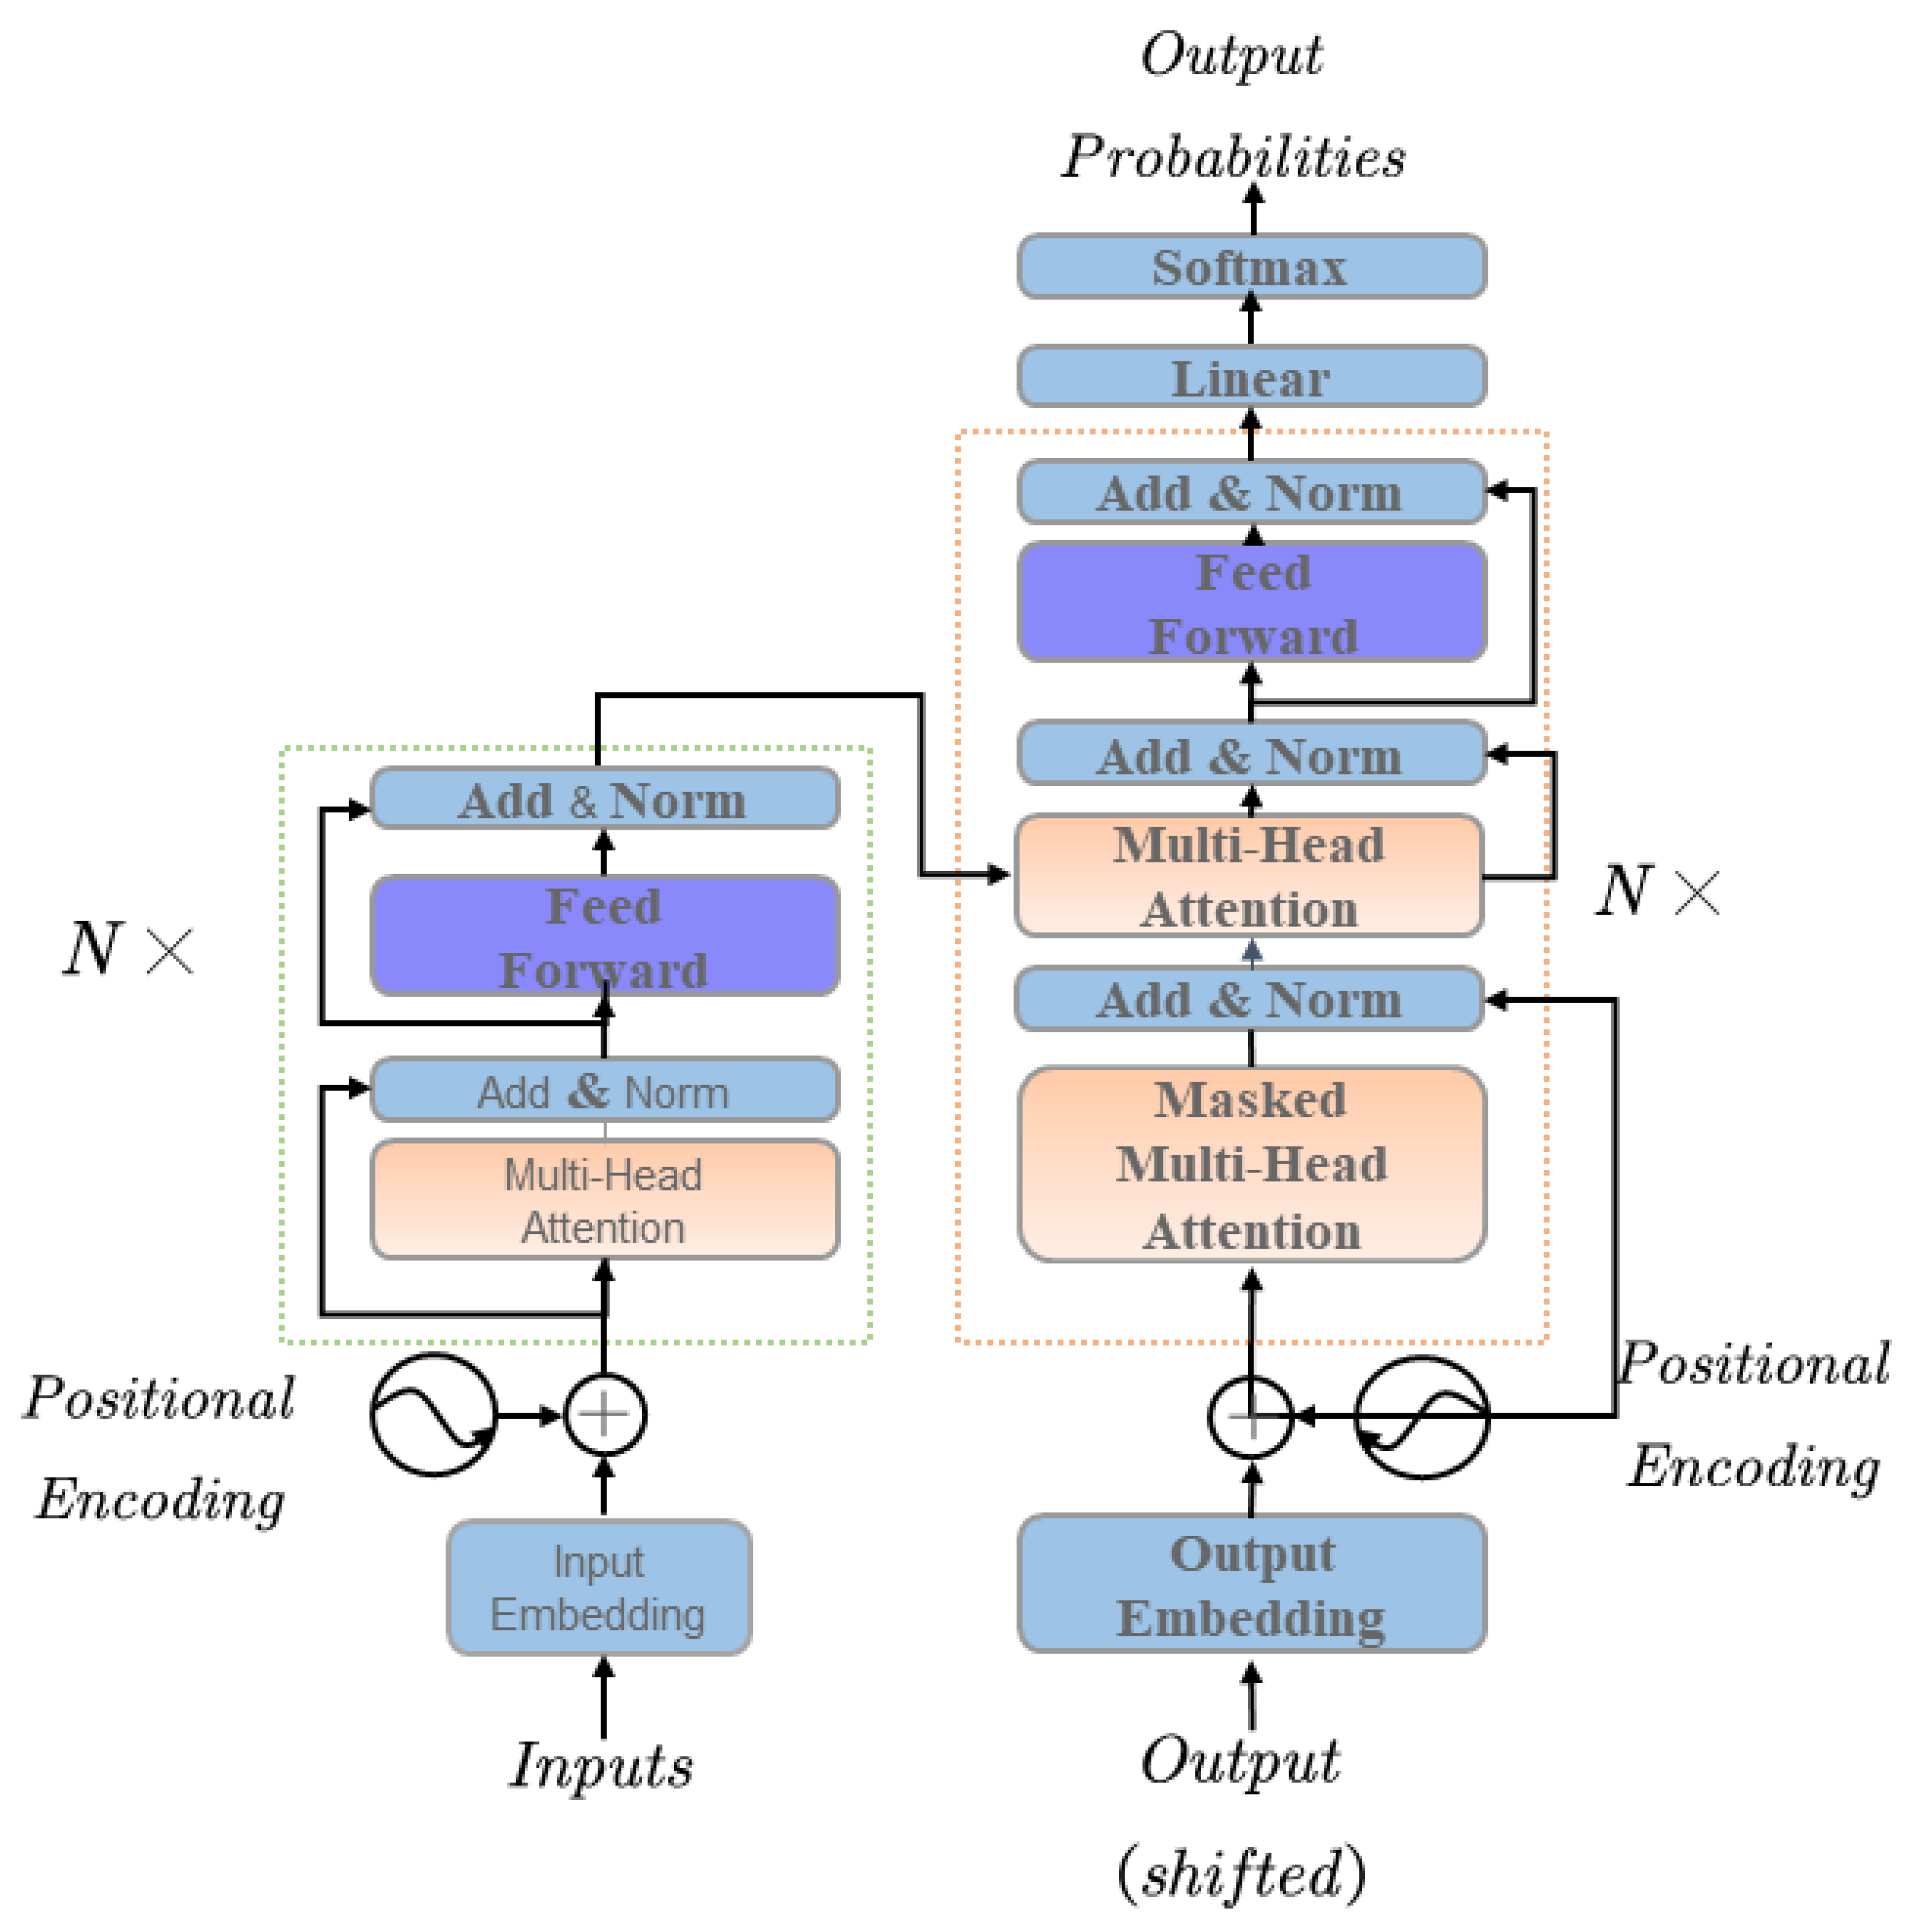

Complete and experiment with this code block (as well as some of the aspects of network definition and training!), and see how the model performs. How do songs generated after training with a small number of epochs compare to those generated after a longer duration of training?

In [ ]:
import random # Add this line to import the random module
import re # Add this line to import the re module
from IPython.display import Audio, display # Import Audio and display

def main():
    print(" Loading dataset and Transformer model...")
    import mitdeeplearning as mdl
    songs = mdl.lab1.load_training_data()

    vocab = sorted(set("".join(songs)))
    char2idx = {u: i for i, u in enumerate(vocab)}
    idx2char = np.array(vocab)

    # Load Transformer model with updated parameters
    try:
        seq_length = 100
        vocab_size = len(vocab)
        embed_dim = 256
        num_heads = 4
        ff_dim = 1024
        num_layers = 2

        transformer_model = create_transformer_model(seq_length, vocab_size, embed_dim, num_heads, ff_dim, num_layers)
        dummy_input = tf.zeros((1, seq_length), dtype=tf.int32)
        _ = transformer_model(dummy_input)
        transformer_model.load_weights("/content/training_checkpoints/my_ckpt.weights.h5")
        print(" Transformer model loaded successfully.")

    except Exception as e:
        print(f" Failed to load Transformer model: {e}")
        return

    # Pick original song
    original_song = random.choice(songs)
    original_length = len(original_song)

    print(f"\n Selected original song ({original_length} characters):")
    print(original_song[:200] + "...")

    # 1. GENERATED: Create a completely new song using Transformer
    print(f"\n Creating GENERATED song (new composition)...")
    generated_song = generate_long_song_by_chaining(
        transformer_model, char2idx, idx2char, target_length=original_length * 2, seq_length=seq_length
    )

    # 2. RECONSTRUCTED: Attempt to recreate the selected original song
    print(f"\n Creating RECONSTRUCTED song (recreating selected song)...")
    reconstructed_song = reconstruct_original_song(
        transformer_model, original_song, char2idx, idx2char, seq_length
    )

    # Fix both for audio conversion
    generated_song = fix_abc_for_audio(generated_song)
    reconstructed_song = fix_abc_for_audio(reconstructed_song)

    # Save files with clear names
    with open("1_original_song.abc", "w") as f:
        f.write(original_song)
    with open("2_generated_song.abc", "w") as f:
        f.write(generated_song)
    with open("3_reconstructed_song.abc", "w") as f:
        f.write(reconstructed_song)

    # Length comparison
    print(f"\n Song comparison:")
    print(f"ORIGINAL:      {len(original_song):4d} chars")
    print(f"GENERATED:     {len(generated_song):4d} chars")
    print(f"RECONSTRUCTED: {len(reconstructed_song):4d} chars")

    # Count notes
    orig_notes = len(re.findall(r'[A-Ga-g]', original_song))
    gen_notes = len(re.findall(r'[A-Ga-g]', generated_song))
    rec_notes = len(re.findall(r'[A-Ga-g]', reconstructed_song))

    print(f"ORIGINAL notes:      {orig_notes}")
    print(f"GENERATED notes:     {gen_notes}")
    print(f"RECONSTRUCTED notes: {rec_notes}")

    # Convert to audio
    print("\n Converting to audio...")
    original_audio = convert_abc_to_audio(original_song, "1_original_song")
    generated_audio = convert_abc_to_audio(generated_song, "2_generated_song")
    reconstructed_audio = convert_abc_to_audio(reconstructed_song, "3_reconstructed_song")

    # Play audio with clear descriptions
    print("\n🎧 AUDIO COMPARISON:")

    if original_audio:
        print(f"\n 1. ORIGINAL (the selected song):")
        display(Audio(filename=original_audio))

    if generated_audio:
        print(f"\n 2. GENERATED (new Transformer composition):")
        display(Audio(filename=generated_audio))

    if reconstructed_audio:
        print(f"\n 3. RECONSTRUCTED (Transformer trying to recreate the original):\n")
        display(Audio(filename=reconstructed_audio))

    print("\n Compare how well the Transformer reconstructed vs. generated new music!")

# === Function to Reconstruct the Original Song ===
def reconstruct_original_song(transformer_model, original_song, char2idx, idx2char, seq_length=100):
    """Direct reconstruction that preserves original musical structure"""
    print(" Reconstructing the original song through Transformer...")

    # Extract header to preserve it exactly
    header_match = re.search(r'(X:.*?K:[^\n]+\n)', original_song, re.DOTALL)
    if header_match:
        header = header_match.group(1)
        body = original_song[len(header):]
    else:
        header = "X:1\nT:Reconstructed\nM:4/4\nL:1/8\nK:C\n"
        body = original_song

    # Add tempo if not present in header
    if "Q:" not in header:
        header = re.sub(r'(K:[^\n]+\n)', r'\1Q:1/4=120\n', header)

    # Extract the musical structure from the original - bar lines and repeated sections
    structure_template = re.sub(r'[A-Ga-g,\'0-9\^\_\=]', 'x', body)  # Replace notes with x

    # Process the body in small chunks with focus on musical motifs
    original_notes = re.findall(r'[A-Ga-g][,\'0-9]*', body)
    original_bars = body.split('|')

    print(f" Original song has {len(original_notes)} notes across {len(original_bars)} bars")

    # Direct approach: Use the transformer to predict each bar
    reconstructed_bars = []

    # For each bar in the original
    for i, bar in enumerate(tqdm(original_bars, desc="Processing bars")):
        if not bar.strip():  # Skip empty bars
            continue

        # Find notes in this bar
        bar_notes = re.findall(r'[A-Ga-g][,\'0-9]*', bar)
        if not bar_notes:  # Skip bars without notes
            reconstructed_bars.append(bar)
            continue

        # Use context from original as seed
        seed = "".join(original_bars[:i])[-64:] if i > 0 else header
        seed_indices = [char2idx.get(c, 0) for c in seed]

        # Pad to sequence length
        if len(seed_indices) < seq_length:
            seed_indices = [0] * (seq_length - len(seed_indices)) + seed_indices
        else:
            seed_indices = seed_indices[-seq_length:]

        # Generate a bar with transformer
        input_tensor = tf.expand_dims(seed_indices, 0)
        output = transformer_model(input_tensor)

        # Extract most likely tokens
        predicted_indices = tf.argmax(output[0], axis=-1).numpy()
        predicted_chars = [idx2char[idx] for idx in predicted_indices[-min(32, len(predicted_indices)):]]
        predicted_text = ''.join(predicted_chars)

        # Extract notes from prediction
        predicted_notes = re.findall(r'[A-Ga-g][,\'0-9]*', predicted_text)

        # If no notes predicted, use some from the original
        if not predicted_notes and bar_notes:
            predicted_notes = bar_notes

        # Recreate bar structure with predicted notes
        bar_template = re.sub(r'[A-Ga-g,\'0-9]*', 'NOTE', bar)
        reconstructed_bar = bar_template

        # Replace NOTE placeholders with actual notes
        for j, note in enumerate(predicted_notes):
            if 'NOTE' in reconstructed_bar:
                reconstructed_bar = reconstructed_bar.replace('NOTE', note, 1)
            else:
                reconstructed_bar += note + " "

        # Ensure bar ends with |
        if not reconstructed_bar.endswith('|'):
            reconstructed_bar += ' |'

        reconstructed_bars.append(reconstructed_bar)

    # Combine bars
    reconstructed_body = ''.join(reconstructed_bars)

    # Check note count
    original_note_count = len(re.findall(r'[A-Ga-g]', body))
    reconstructed_note_count = len(re.findall(r'[A-Ga-g]', reconstructed_body))

    # If not enough notes, supplement with original material
    if reconstructed_note_count < original_note_count * 0.7:
        print(f" Still insufficient notes ({reconstructed_note_count} vs {original_note_count})")
        print(" Adding original motifs to enhance reconstruction")

        # Extract musical phrases from original
        phrases = []
        for bar in original_bars:
            if len(bar.strip()) > 3:  # Non-empty bar
                phrases.append(bar)

        # Add some original phrases
        sample_count = max(1, (original_note_count - reconstructed_note_count) // 20)
        selected_phrases = random.sample(phrases, min(sample_count, len(phrases)))

        for phrase in selected_phrases:
            reconstructed_body += phrase

    # Final processing
    reconstructed_body = fix_music_structure(reconstructed_body)

    # Complete song
    result = header + reconstructed_body

    # Final note count
    final_note_count = len(re.findall(r'[A-Ga-g]', result))

    print(f"Reconstructed {len(result)} characters (original was {len(original_song)}) ")
    print(f"Original notes: {original_note_count}, Reconstructed notes: {final_note_count}")

    return result

def fix_music_structure(music_text):
    """Fix common ABC notation structural issues"""
    # Ensure bar lines are properly spaced
    music_text = re.sub(r'\|\s*\|', '|', music_text)

    # Remove invalid characters often appearing in generated music
    music_text = re.sub(r'[^ABCDEFGabcdefgz0-9\|\[\]\/\(\)\^\=\_\,\'\~\:\-\+ ]', '', music_text)

    # Ensure proper bar line spacing
    music_text = re.sub(r'([A-Ga-g][0-9]?[,\']*)(?!\||\s)', r'\1 ', music_text)

    # Fix trailing bars
    if not music_text.endswith('|'):
        music_text += ' |'

    return music_text

def fix_abc_for_audio(abc_text):
    """Enhanced ABC fixer for audio conversion"""
    # First apply the basic structure fixes
    abc_text = fix_music_structure(abc_text)

    # Make sure we have a proper header
    if not re.search(r'X:', abc_text):
        abc_text = "X:1\nT:Generated Music\nM:4/4\nL:1/8\nK:C\n" + abc_text

    # Make sure we have a tempo marking to prevent extremely slow playback
    if not re.search(r'Q:', abc_text):
        # Insert tempo after the key
        abc_text = re.sub(r'(K:[^\n]+\n)', r'\1Q:1/4=120\n', abc_text)

    # Replace any problematic repeat sections that might cause loop issues
    abc_text = re.sub(r'\|\:\s*\|\:', '|', abc_text)

    # Ensure proper ending
    if not abc_text.endswith('|'):
        abc_text += ' |'

    return abc_text

def clean_abc_segment(segment):
    """Clean a small segment of ABC notation"""
    # Remove invalid characters
    cleaned = re.sub(r'[^ABCDEFGabcdefgz0-9\|\[\]\/\(\)\^\=\_\,\'\~\:\-\+ ]', '', segment)
    return cleaned

def convert_abc_to_audio(abc_text, filename_base, attempts=3):
    """Improved ABC to audio conversion with retry logic"""
    # Create output directory if needed
    output_dir = "audio_output"
    os.makedirs(output_dir, exist_ok=True)

    # Fully process the ABC text to ensure it's valid
    processed_abc = fix_abc_for_audio(abc_text)

    # Save processed ABC to file
    abc_file = f"{output_dir}/{filename_base}.abc"
    with open(abc_file, "w") as f:
        f.write(processed_abc)

    # Convert to WAV
    wav_file = f"{output_dir}/{filename_base}.wav"

    for attempt in range(attempts):
        try:
            print(f"Converting {filename_base} to WAV...")
            os.system(f"abc2midi {abc_file} -o {output_dir}/{filename_base}.mid")
            os.system(f"timidity {output_dir}/{filename_base}.mid -Ow -o {wav_file}")

            if os.path.exists(wav_file):
                print(f"Created WAV file: {wav_file}")
                return wav_file
            else:
                print(f"Attempt {attempt+1}: Failed to create WAV file")
        except Exception as e:
            print(f"Attempt {attempt+1}: Error processing {filename_base}: {e}")

    print(f"Failed to convert {filename_base} after {attempts} attempts")
    return None

def generate_long_song_by_chaining(model, char2idx, idx2char, target_length=500, seq_length=100, temperature=1.0):
    """Generate a longer song by chaining multiple generations together"""
    # Initialize with a standard ABC notation header
    header = "X:1\nT:Generated Song\nM:4/4\nL:1/8\nK:C\n"

    # Start with a seed from the header
    input_indices = [char2idx.get(c, 0) for c in header]

    # Generate the song in segments
    full_song = header
    current_length = len(header)

    with tqdm(total=target_length//seq_length, desc="Generating segments") as pbar:
        while current_length < target_length:
            # Take the last seq_length tokens (or pad if needed)
            if len(input_indices) > seq_length:
                input_indices = input_indices[-seq_length:]
            elif len(input_indices) < seq_length:
                padding = [0] * (seq_length - len(input_indices))
                input_indices = padding + input_indices

            # Convert to tensor and predict
            input_tensor = tf.expand_dims(input_indices, 0)
            predictions = model(input_tensor)

            # Sample from the predictions
            predictions = predictions[0] / temperature
            predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

            # Append the predicted character to the input
            input_indices.append(predicted_id)
            char = idx2char[predicted_id]
            full_song += char
            current_length += 1

            # Update progress every few characters
            if current_length % seq_length == 0:
                pbar.update(1)

            # Break if generated song is getting too long
            if current_length >= target_length * 2:
                break

    # Clean up the generated song for better playability
    full_song = fix_abc_for_audio(full_song)

    return full_song

if __name__ == "__main__":
    main()

## 1.8 Evaluation: Comparing Generated and Original Songs
### Metrics: Jaccard, Pitch Histogram, Repetition, n-gram, Contour,Coherence, BLEU Score, Sequence Similarity


In [ ]:
from music21 import converter, note
from collections import Counter
from difflib import SequenceMatcher
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import re

# --- Enhanced ABC fixing function ---
def fix_abc_notation_enhanced(abc_text):
    lines = abc_text.split('\n')
    fixed_lines = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Fix specific malformed headers
        if line.startswith('M::'):
            line = 'M:4/4'  # Default meter
        elif line.startswith('M:') and line == 'M:':
            line = 'M:4/4'
        elif line.startswith('L::'):
            line = 'L:1/8'  # Default note length
        elif line.startswith('L:') and line == 'L:':
            line = 'L:1/8'
        elif line.startswith('K::'):
            line = 'K:C'    # Default key
        elif line.startswith('K:') and line == 'K:':
            line = 'K:C'
        elif line.startswith('T::'):
            line = 'T:Generated Song'
        elif line.startswith('T:') and line == 'T:':
            line = 'T:Generated Song'
        elif line.startswith('X::'):
            line = 'X:1'
        elif line.startswith('X:') and line == 'X:':
            line = 'X:1'
        # Handle empty headers with just colon
        elif ':' in line and line.endswith(':'):
            header = line.split(':')[0]
            if header == 'M':
                line = 'M:4/4'
            elif header == 'L':
                line = 'L:1/8'
            elif header == 'K':
                line = 'K:C'
            elif header == 'T':
                line = 'T:Generated Song'
            elif header == 'X':
                line = 'X:1'

        fixed_lines.append(line)

    return '\n'.join(fixed_lines)

# --- Updated parsing function ---
def parse_abc_notes_fixed(abc_text, filename=""):
    print(f"\n=== PARSING ABC: {filename} ===")

    if not abc_text.strip():
        print("Empty ABC content")
        return []

    # Try direct parsing first
    try:
        print("Attempt 1: Direct music21 parsing...")
        parsed = converter.parse(abc_text, format='abc')
        notes = parsed.flatten().notes
        note_names = [n.nameWithOctave for n in notes if isinstance(n, note.Note)]
        print(f"Success! Extracted {len(note_names)} notes")
        return note_names
    except Exception as e:
        print(f"Failed: {e}")

    # Apply enhanced fixes and retry
    try:
        print("Attempt 2: Enhanced ABC fixing...")
        fixed_abc = fix_abc_notation_enhanced(abc_text)

        # Show what was fixed
        if fixed_abc != abc_text:
            print("Applied fixes:")
            original_lines = abc_text.split('\n')
            fixed_lines = fixed_abc.split('\n')
            for i, (orig, fixed) in enumerate(zip(original_lines, fixed_lines)):
                if orig != fixed:
                    print(f"  Line {i+1}: '{orig}' → '{fixed}'")

        parsed = converter.parse(fixed_abc, format='abc')
        notes = parsed.flatten().notes
        note_names = [n.nameWithOctave for n in notes if isinstance(n, note.Note)]
        print(f"Success after enhanced fixes! Extracted {len(note_names)} notes")
        return note_names
    except Exception as e:
        print(f"Enhanced fixing failed: {e}")

    # Fallback to manual extraction
    try:
        print("Attempt 3: Manual note extraction...")
        notes = extract_notes_manually(abc_text)
        if notes:
            print(f"✓ Manual extraction found {len(notes)} notes")
            return notes
    except Exception as e:
        print(f"Manual extraction failed: {e}")

    print("All parsing attempts failed")
    return []

# --- Manual note extraction (improved) ---
def extract_notes_manually(abc_text):
    lines = abc_text.split('\n')
    note_lines = []

    # Skip header lines and collect note content
    for line in lines:
        line = line.strip()
        # Skip empty lines and headers
        if not line or line.startswith(('X:', 'T:', 'M:', 'L:', 'K:', 'Q:', 'Z:', '%')):
            continue
        note_lines.append(line)

    if not note_lines:
        return []

    # Combine all note content and clean it
    note_content = ' '.join(note_lines)

    # Remove bar lines, repeat marks, and other symbols
    note_content = re.sub(r'[|\[\]!:]', ' ', note_content)

    # Extract notes with regex (handles various ABC notation)
    note_pattern = r'[A-Ga-g][#b]?[,\']*[0-9]*'
    matches = re.findall(note_pattern, note_content)

    # Convert to standard note names
    notes = []
    for match in matches:
        # Remove duration numbers
        clean_note = re.sub(r'[0-9]', '', match)
        if clean_note:  # Only process non-empty notes
            try:
                n = note.Note(clean_note)
                notes.append(n.nameWithOctave)
            except:
                continue

    return notes

# --- Keep all your original evaluation functions ---
def jaccard_overlap(a, b):
    set_a, set_b = set(a), set(b)
    return len(set_a & set_b) / len(set_a | set_b) if (set_a | set_b) else 0

def pitch_class_histogram(notes):
    h = {p: 0 for p in "CDEFGAB"}
    for n in notes:
        if n[0] in h:
            h[n[0]] += 1
    total = sum(h.values()) or 1
    return {k: v / total for k, v in h.items()}

def histogram_difference(h1, h2):
    return sum(abs(h1[k] - h2[k]) for k in h1)

def repetition_factor(notes):
    return sum(notes.count(n) for n in set(notes)) / len(notes) if notes else 0

def ngram_overlap(a, b, n=2):
    def extract_ngrams(seq, n):
        return Counter(tuple(seq[i:i+n]) for i in range(len(seq) - n + 1))
    a_ngrams = extract_ngrams(a, n)
    b_ngrams = extract_ngrams(b, n)
    shared = sum((a_ngrams & b_ngrams).values())
    total = sum((a_ngrams | b_ngrams).values())
    return shared / total if total else 0

def melodic_contour(notes):
    def to_midi(n):
        try: return note.Note(n).pitch.midi
        except: return None
    mids = [to_midi(n) for n in notes if n]
    mids = [m for m in mids if m is not None]
    contour = []
    for i in range(1, len(mids)):
        if mids[i] > mids[i-1]: contour.append('U')
        elif mids[i] < mids[i-1]: contour.append('D')
        else: contour.append('S')
    return contour

def contour_similarity(c1, c2):
    return SequenceMatcher(None, c1, c2).ratio()

def musical_coherence(notes):
    def to_midi(n):
        try: return note.Note(n).pitch.midi
        except: return None
    mids = [to_midi(n) for n in notes if n]
    mids = [m for m in mids if m is not None]
    if len(mids) < 2: return 1.0
    intervals = [mids[i+1] - mids[i] for i in range(len(mids) - 1)]
    std_dev = np.std(intervals)
    max_possible = 87
    return 1.0 - min(1.0, std_dev / max_possible)

def compute_bleu(reference, candidate):
    try:
        smoothing = SmoothingFunction().method1
        return sentence_bleu([reference], candidate, smoothing_function=smoothing)
    except Exception:
        return 0.0

def sequence_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

def evaluate_similarity(original_notes, generated_notes):
    if not original_notes or not generated_notes:
        print("One or both note sequences are empty. Check ABC content.")
        return

    print("\n MUSIC SIMILARITY EVALUATION")
    print("="*50)
    print(f" Original: {len(original_notes)} notes | Generated: {len(generated_notes)} notes")
    print(f"\n Similarity Metrics:")
    print(f"   Note Overlap (Jaccard):        {jaccard_overlap(original_notes, generated_notes):.3f}")

    h_orig = pitch_class_histogram(original_notes)
    h_gen = pitch_class_histogram(generated_notes)
    print(f"   Pitch Class Histogram Δ:       {histogram_difference(h_orig, h_gen):.3f}")
    print(f"   Repetition Factor (original):  {repetition_factor(original_notes):.3f}")
    print(f"   Repetition Factor (generated): {repetition_factor(generated_notes):.3f}")
    print(f"   Bigram Overlap:                {ngram_overlap(original_notes, generated_notes, 2):.3f}")
    print(f"   Trigram Overlap:               {ngram_overlap(original_notes, generated_notes, 3):.3f}")

    contour_orig = melodic_contour(original_notes)
    contour_gen = melodic_contour(generated_notes)
    print(f"   Melodic Contour Similarity:    {contour_similarity(contour_orig, contour_gen):.3f}")
    print(f"   Musical Coherence (original):  {musical_coherence(original_notes):.3f}")
    print(f"   Musical Coherence (generated): {musical_coherence(generated_notes):.3f}")
    print(f"   BLEU Score:                    {compute_bleu(original_notes, generated_notes):.3f}")
    print(f"   Sequence Similarity:           {sequence_similarity(original_notes, generated_notes):.3f}")

# --- Load ABC from file ---
def load_abc_from_file(filepath):
    try:
        with open(filepath, 'r') as f:
            return f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return ""

# --- Main execution ---
original_song = load_abc_from_file("/content/audio_output/1_original_song.abc")
reconstructed_song = load_abc_from_file("/content/audio_output/3_reconstructed_song.abc")

# Use the enhanced parsing function
original_notes = parse_abc_notes_fixed(original_song, "original")
reconstructed_notes = parse_abc_notes_fixed(reconstructed_song, "reconstructed")

evaluate_similarity(original_notes, reconstructed_notes)

#Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from music21 import converter, note
from collections import Counter
import re

# --- Enhanced ABC fixing function ---
def fix_abc_notation_enhanced(abc_text):
    lines = abc_text.split('\n')
    fixed_lines = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Fix specific malformed headers
        if line.startswith('M::'):
            line = 'M:4/4'
        elif line.startswith('M:') and line == 'M:':
            line = 'M:4/4'
        elif line.startswith('L::'):
            line = 'L:1/8'
        elif line.startswith('L:') and line == 'L:':
            line = 'L:1/8'
        elif line.startswith('K::'):
            line = 'K:C'
        elif line.startswith('K:') and line == 'K:':
            line = 'K:C'
        elif line.startswith('T::'):
            line = 'T:Generated Song'
        elif line.startswith('T:') and line == 'T:':
            line = 'T:Generated Song'
        elif line.startswith('X::'):
            line = 'X:1'
        elif line.startswith('X:') and line == 'X:':
            line = 'X:1'
        elif ':' in line and line.endswith(':'):
            header = line.split(':')[0]
            if header == 'M':
                line = 'M:4/4'
            elif header == 'L':
                line = 'L:1/8'
            elif header == 'K':
                line = 'K:C'
            elif header == 'T':
                line = 'T:Generated Song'
            elif header == 'X':
                line = 'X:1'

        fixed_lines.append(line)

    return '\n'.join(fixed_lines)

# --- Load ABC from file ---
def load_abc_from_file(filepath):
    try:
        with open(filepath, 'r') as f:
            return f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return ""

# --- Enhanced ABC parsing with error handling ---
def parse_abc_notes_fixed(abc_text, filename=""):
    print(f"\n=== PARSING ABC: {filename} ===")

    if not abc_text.strip():
        print(" Empty ABC content")
        return []

    # Try direct parsing first
    try:
        print("Attempt 1: Direct music21 parsing...")
        parsed = converter.parse(abc_text, format='abc')
        notes = parsed.flatten().notes
        note_names = [n.nameWithOctave for n in notes if isinstance(n, note.Note)]
        print(f"Success! Extracted {len(note_names)} notes")
        return note_names
    except Exception as e:
        print(f"Failed: {e}")

    # Apply enhanced fixes and retry
    try:
        print("Attempt 2: Enhanced ABC fixing...")
        fixed_abc = fix_abc_notation_enhanced(abc_text)

        # Show what was fixed
        if fixed_abc != abc_text:
            print("Applied fixes:")
            original_lines = abc_text.split('\n')
            fixed_lines = fixed_abc.split('\n')
            for i, (orig, fixed) in enumerate(zip(original_lines, fixed_lines)):
                if orig != fixed:
                    print(f"  Line {i+1}: '{orig}' → '{fixed}'")

        parsed = converter.parse(fixed_abc, format='abc')
        notes = parsed.flatten().notes
        note_names = [n.nameWithOctave for n in notes if isinstance(n, note.Note)]
        print(f" Success after enhanced fixes! Extracted {len(note_names)} notes")
        return note_names
    except Exception as e:
        print(f" Enhanced fixing failed: {e}")

    print(" All parsing attempts failed")
    return []

# --- Align sequences for fair comparison ---
def align_sequences(seq1, seq2):
    """Align sequences to same length for meaningful comparison"""
    min_length = min(len(seq1), len(seq2))
    return seq1[:min_length], seq2[:min_length]

# --- Create unified vocabulary ---
def create_unified_vocabulary(seq1, seq2):
    """Create unified vocabulary from both sequences"""
    all_notes = set(seq1 + seq2)
    vocab = sorted(list(all_notes))
    note_to_id = {note: i for i, note in enumerate(vocab)}
    return vocab, note_to_id

# --- Enhanced Confusion Matrix Plot ---
def plot_confusion_matrix(y_true_notes, y_pred_notes, title="Confusion Matrix"):
    """Enhanced confusion matrix that handles different vocabularies and sequence lengths"""

    if not y_true_notes or not y_pred_notes:
        print(" Cannot create confusion matrix: empty sequences")
        return

    print(f"\n Creating confusion matrix...")
    print(f"   Original: {len(y_true_notes)} notes")
    print(f"   Generated: {len(y_pred_notes)} notes")

    # Align sequences to same length
    y_true_aligned, y_pred_aligned = align_sequences(y_true_notes, y_pred_notes)
    print(f"   Aligned length: {len(y_true_aligned)}")

    if len(y_true_aligned) == 0:
        print(" No notes to compare after alignment")
        return

    # Create unified vocabulary
    vocab, note_to_id = create_unified_vocabulary(y_true_aligned, y_pred_aligned)

    # Convert to IDs
    y_true_ids = [note_to_id[note] for note in y_true_aligned]
    y_pred_ids = [note_to_id[note] for note in y_pred_aligned]

    # Create confusion matrix
    cm = confusion_matrix(y_true_ids, y_pred_ids, labels=range(len(vocab)))

    # Calculate accuracy
    accuracy = sum(1 for t, p in zip(y_true_ids, y_pred_ids) if t == p) / len(y_true_ids)

    # Create the plot
    plt.figure(figsize=(max(8, len(vocab) * 0.6), max(6, len(vocab) * 0.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=vocab, yticklabels=vocab)
    plt.xlabel("Predicted Notes")
    plt.ylabel("True Notes")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
if __name__ == "__main__":
    print(" ABC Confusion Matrix Analysis")
    print("="*50)

    # Load the files
    original_song = load_abc_from_file("/content/audio_output/1_original_song.abc")
    reconstructed_song = load_abc_from_file("/content/audio_output/3_reconstructed_song.abc")

    # Parse using the correct function name
    original_notes = parse_abc_notes_fixed(original_song, "original")
    reconstructed_notes = parse_abc_notes_fixed(reconstructed_song, "reconstructed")

    # Create confusion matrix
    if original_notes and reconstructed_notes:
        plot_confusion_matrix(original_notes, reconstructed_notes,
                             "Original vs Reconstructed Notes")
    else:
        print(" Could not create confusion matrix: parsing failed")

#Audio Similarity(DTW)

In [ ]:
import librosa
import numpy as np
from librosa.sequence import dtw

# --- Audio Similarity using DTW over MFCCs ---
def compute_audio_similarity_dtw(file1, file2, sr=22050, n_mfcc=20):
    try:
        # Load audio
        y1, _ = librosa.load(file1, sr=sr)
        y2, _ = librosa.load(file2, sr=sr)

        # Extract MFCCs (shape: n_mfcc × time)
        mfcc1 = librosa.feature.mfcc(y=y1, sr=sr, n_mfcc=n_mfcc)
        mfcc2 = librosa.feature.mfcc(y=y2, sr=sr, n_mfcc=n_mfcc)

        # Compute DTW (match MFCC features over time using cosine distance)
        D, wp = dtw(X=mfcc1, Y=mfcc2, metric='cosine')

        # Normalize distance by length of path
        dist = D[-1, -1] / len(wp)
        similarity = 1 / (1 + dist)  # Higher is better
        print(f"DTW Audio Similarity: {similarity:.2f}")
        return similarity

    except Exception as e:
        print(f"Error during DTW audio comparison: {e}")
        return 0.0

# --- Example Usage ---
if __name__ == "__main__":
    file1 = "/content/audio_output/1_original_song.wav"
    file2 = "/content/audio_output/3_reconstructed_song.wav"
    compute_audio_similarity_dtw(file1, file2)

#Music Spectogram

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the original audio file
original_audio_path = "/content/audio_output/1_original_song.wav"  # Or "original_song.mp3"
y_orig, sr_orig = librosa.load(original_audio_path, sr=None)

# Create and display spectrogram for original music
plt.figure(figsize=(10, 4))
S_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr_orig)
librosa.display.specshow(librosa.power_to_db(S_orig, ref=np.max),
                         sr=sr_orig, x_axis='time', y_axis='mel')
plt.title("Original Music Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

# Load generated audio file
generated_audio_path = "/content/audio_output/3_reconstructed_song.wav"  # or .wav
y_gen, sr_gen = librosa.load(generated_audio_path, sr=None)

# Create and display spectrogram for generated music
plt.figure(figsize=(10, 4))
S_gen = librosa.feature.melspectrogram(y=y_gen, sr=sr_gen)
librosa.display.specshow(librosa.power_to_db(S_gen, ref=np.max),
                         sr=sr_gen, x_axis='time', y_axis='mel')
plt.title("Generated Music Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

## Generating Multiple songs

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
from IPython.display import Audio, display
from tqdm import tqdm
import re

# Fix ABC rhythm
def fix_abc_rhythm(abc_string):
    header_match = re.search(r'(X:.*?K:[^\n]+\n)', abc_string, re.DOTALL)
    header = header_match.group(1) if header_match else "X:1\nT:Generated\nM:4/4\nL:1/8\nK:C\n"

    if "Q:" not in header:
        header += "Q:1/4=30\n"

    body = abc_string.replace(header, "") if header else abc_string
    body = re.sub(r'[zZxX]|[|:\[\]]+', '', body)
    notes = re.findall(r"[A-Ga-g][,']*", body)

    durations = ["1/4", "1/8", "1/4", "1/8"]
    cleaned_notes = [note + durations[i % len(durations)] for i, note in enumerate(notes)]

    measures = [" ".join(cleaned_notes[i:i+8]) for i in range(0, len(cleaned_notes), 8)]
    final_body = " |\n".join(measures) + " |"

    return header + final_body + "\n"

#  Generate song from model
def generate_song_from_model(model, char2idx, idx2char, start_string, generation_length=1500, temperature=0.5):
    input_eval = [char2idx.get(c, 0) for c in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    generated_song = []
    if hasattr(model, 'reset_states'):
        model.reset_states()

    for _ in tqdm(range(generation_length), desc="Generating"):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        generated_song.append(idx2char[predicted_id])
        input_eval = tf.expand_dims([predicted_id], 0)

    raw_output = start_string + ''.join(generated_song)
    cleaned_output = fix_abc_rhythm(raw_output)
    return cleaned_output

# Convert ABC to audio
def convert_abc_to_audio(abc_text, filename):
    try:
        abc_path = f"{filename}.abc"
        with open(abc_path, "w") as f:
            f.write(abc_text)

        midi_path = f"{filename}.mid"
        os.system(f"abc2midi {abc_path} -o {midi_path} > /dev/null 2>&1")
        print(f" MIDI saved: {midi_path}")

        wav_path = f"{filename}.wav"
        os.system(f"timidity {midi_path} -Ow -o {wav_path} > /dev/null 2>&1")
        print(f" WAV saved: {wav_path}")

        return wav_path
    except Exception as e:
        print(f" Error converting {filename}: {e}")
        return None

#  Transformer model classes
class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TransformerModel(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim=256, num_heads=4, ff_dim=1024, num_layers=2, dropout_rate=0.1):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.pos_encoding = self.positional_encoding(1000, embedding_dim)
        self.encoder_layers = [
            TransformerEncoderBlock(embedding_dim, num_heads, ff_dim, dropout_rate)
            for _ in range(num_layers)
        ]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.dense = tf.keras.layers.Dense(vocab_size)

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    def call(self, inputs, training=False):
        seq_len = tf.shape(inputs)[1]
        x = self.embedding(inputs)
        x += self.pos_encoding[:, :seq_len, :]
        for encoder in self.encoder_layers:
            x = encoder(x, training=training)
        x = self.dropout(x, training=training)
        return self.dense(x)

#  Main function
def main(num_songs=5):  # You can set how many songs to generate
    print(" Loading dataset and model...")
    import mitdeeplearning as mdl
    songs = mdl.lab1.load_training_data()

    vocab = sorted(set("".join(songs)))
    char2idx = {u: i for i, u in enumerate(vocab)}
    idx2char = np.array(vocab)

    # Load model
    model = TransformerModel(len(vocab))
    try:
        model.build((1, None))
        model.load_weights("./training_checkpoints/my_ckpt.weights.h5")
        print(" Model loaded successfully")
    except Exception as e:
        print(f" Failed to load model: {e}")
        return

    for i in range(num_songs):
        print(f"\n====================  Pair {i+1} ====================")
        original_song = random.choice(songs)
        seed_string = original_song[:50]

        generated_song = generate_song_from_model(
            model, char2idx, idx2char,
            start_string=seed_string,
            generation_length=1500,
            temperature=0.5
        )

        # Save both songs
        with open(f"original_song_{i+1}.abc", "w") as f:
            f.write(original_song)

        with open(f"generated_song_{i+1}.abc", "w") as f:
            f.write(generated_song)

        # Convert to audio
        original_audio = convert_abc_to_audio(original_song, f"original_song_{i+1}")
        generated_audio = convert_abc_to_audio(generated_song, f"generated_song_{i+1}")

        # Playback
        if original_audio:
            print(f"\n Playing original song {i+1}:")
            display(Audio(filename=original_audio))

        if generated_audio:
            print(f"\n Playing generated song {i+1}:")
            display(Audio(filename=generated_audio))

# Run
if __name__ == "__main__":
    main(num_songs=8)  # Change to desired number
